#### Load the model

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from huggingface_hub import login

login(token="hf_XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")



model_id = "meta-llama/Llama-3.2-1B"

# 4-bit quantization configuration
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)


tokenizer.pad_token = tokenizer.eos_token

In [ ]:
import numpy as np
import torch

def generate_freqmark_text(prompt, num_tokens=200, top_p=0.95):
    device = model.device
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    prompt_len = input_ids.shape[1]
    generated_ranks = []


    test_token = tokenizer.tokenize(" test")[0]
    space_char = test_token[0] if not test_token[0].isalnum() else None

    for i in range(num_tokens): 
        with torch.no_grad():
            outputs = model(input_ids) 
            logits = outputs.logits[:, -1, :] 

     
        probs = torch.softmax(logits, dim=-1)
        sorted_probs, sorted_indices = torch.sort(probs, descending=True)
        
   
        cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

      
        n = input_ids.shape[1]
        target_rank = int(round(3 + 2 * np.sin(2 * np.pi * 0.1 * n)))
        target_rank = max(1, min(5, target_rank))


        top_token_id = sorted_indices[0, 0].item()
        top_token_str = tokenizer.convert_ids_to_tokens(top_token_id)
        

        is_continuation = False
        if space_char and not top_token_str.startswith(space_char):
            is_continuation = True

        is_in_top_p = cumulative_probs[0, target_rank - 1] <= top_p
        
       
        if not is_continuation and is_in_top_p:
            selected_token_id = sorted_indices[0, target_rank - 1].unsqueeze(0).unsqueeze(0)
            generated_ranks.append(target_rank)
        else:
            # FALLBACK: Use Rank 1 to finish words or protect quality
            selected_token_id = sorted_indices[0, 0].unsqueeze(0).unsqueeze(0)
            generated_ranks.append(1) 

       
        input_ids = torch.cat([input_ids, selected_token_id], dim=-1)

        if (i+1) % 20 == 0:
            print(f"Generating token {i+1}/{num_tokens}")

    gen_token = input_ids[0][prompt_len:]
    gen_text = tokenizer.decode(gen_token, skip_special_tokens=True)
    return gen_text, generated_ranks

#test
prompt = "The basic principles of thermodynamics state that"
output_text, ranks = generate_freqmark_text(prompt)

print(f"\nGenerated Text:\n{output_text}")
print(f"\nSequence of Ranks used:\n{ranks}")

Generating token 20/200
Generating token 40/200
Generating token 60/200
Generating token 80/200
Generating token 100/200
Generating token 120/200
Generating token 140/200
Generating token 160/200
Generating token 180/200
Generating token 200/200

Generated Text:
 heat cannot spontaneously pass from the cold end of a system to the hot end, or from the hot end to the cold end.
In a closed system, no external force, like a heat source, is needed to drive this natural law.
In a system where a gas can exchange thermal energy with its environment through the motion of particles (as in a piston or compressor, which in this context is called the working part, see the illustration), the gas is forced into its surroundings. In a system where the particles move as heat flows from one part of the working piston, through it to another part, and back through it.
If we look at the illustration of an isothermal expansion, the gas is pushed from point a into b, where it is in equilibrium. At the beginn

In [ ]:
import torch
import gc

def clear_gpu():
    """Clean up GPU space"""
    gc.collect()
    torch.cuda.empty_cache()

#### Translation Attack

In [ ]:
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM

import torch
import random

device = model.device 

# 1. Load EN -> ES
model_en_es_name = "Helsinki-NLP/opus-mt-en-es"
tokenizer_en_es = AutoTokenizer.from_pretrained(model_en_es_name)
model_en_es = AutoModelForSeq2SeqLM.from_pretrained(model_en_es_name).to(device)

# 2. Load ES -> EN
model_es_en_name = "Helsinki-NLP/opus-mt-es-en"
tokenizer_es_en = AutoTokenizer.from_pretrained(model_es_en_name)
model_es_en = AutoModelForSeq2SeqLM.from_pretrained(model_es_en_name).to(device)

import re

def split_sentences(text):
    return [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if s.strip()]

def attack_translation(text, percentage=1.0):
    sentences = split_sentences(text)
    n = len(sentences)
    
    n_to_translate = max(1, int(n * percentage))
    indices_to_translate = set(random.sample(range(n), n_to_translate))
    
    result = []
    for i, sent in enumerate(sentences):
        if i not in indices_to_translate:
            result.append(sent)
            continue
        
        # English → Spanish
        inputs = tokenizer_en_es(sent, return_tensors="pt", padding=True, truncation=True).to(device)
        with torch.no_grad():
            es_text = tokenizer_en_es.decode(
                model_en_es.generate(**inputs)[0], skip_special_tokens=True
            )
        
        # Spanish → English
        inputs_back = tokenizer_es_en(es_text, return_tensors="pt", padding=True, truncation=True).to(device)
        with torch.no_grad():
            en_back = tokenizer_es_en.decode(
                model_es_en.generate(**inputs_back)[0], skip_special_tokens=True
            )
        
        result.append(en_back)
    
    return " ".join(result)
    clear_gpu()

#### Substitution Attack

In [ ]:
model_id = "google-t5/t5-base"
t5_tokenizer = AutoTokenizer.from_pretrained(model_id)
t5_model = AutoModelForSeq2SeqLM.from_pretrained(model_id, quantization_config=bnb_config, device_map="auto")
def substitution_attack(text, percentage, span_len=3):
    words = text.split()
    n = len(words)

    #non overlapping spans
    positions = list(range(n - span_len + 1))
    random.shuffle(positions)
    masked = set()
    for pos in positions:
        span = set(range(pos, pos + span_len))
        if not span & masked:
            masked.update(span)
        if len(masked) >= int(n * percentage):
            break

    #input
    masked_words, sid, i = [], 0, 0
    while i < n:
        if i in masked:
            masked_words.append(f"<extra_id_{sid}>")
            while i < n and i in masked: i += 1
            sid += 1
        else:
            masked_words.append(words[i]); i += 1

    
    input_ids = t5_tokenizer(" ".join(masked_words), return_tensors="pt").input_ids.to(t5_model.device)
    

    outputs = t5_model.generate(
        input_ids, 
        max_new_tokens=len(masked) + 3,
        do_sample=True,
        temperature=0.3,
        top_p=0.9
    )
    
    decoded = t5_tokenizer.decode(outputs[0], skip_special_tokens=False)

    #reconstruction
    replacements = {int(m.group(1)): m.group(2).strip()
                for m in re.finditer(r"<extra_id_(\d+)>(.*?)(?=<extra_id_|</s>|\Z)", decoded, re.DOTALL)}
    
    span_starts = sorted(p for p in masked if p - 1 not in masked)
    new_words, skip_until, sid = [], -1, 0
    for i, word in enumerate(words):
        if i <= skip_until: continue
        if i in span_starts:
            if sid in replacements and len(replacements[sid]) > 0:
                new_words.append(replacements[sid])
            else:
                j = i
                while j in masked:
                    new_words.append(words[j])
                    j += 1
            
            j = i
            while j in masked: j += 1
            skip_until, sid = j - 1, sid + 1
        else:
            new_words.append(word)

    return " ".join(new_words)

#### Paraphrasing Attack

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import re, random, torch


para_model_name = "humarin/chatgpt_paraphraser_on_T5_base"
para_tokenizer = AutoTokenizer.from_pretrained(para_model_name)
para_model = AutoModelForSeq2SeqLM.from_pretrained(para_model_name).to(device)
para_model.eval()

def _paraphrase_sentence(text):
    input_ids = para_tokenizer(
        f"paraphrase: {text}",
        return_tensors="pt",
        max_length=256,
        truncation=True
    ).input_ids.to(device)

    with torch.no_grad():
        outputs = para_model.generate(
            input_ids,
            max_new_tokens=len(text.split()) * 2 + 15,
            num_beams=5,
            num_beam_groups=5,
            diversity_penalty=1.5,  
            early_stopping=True
        )

    result = para_tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
    return result if len(result) > 2 else text  # fallback to original

def attack_paraphrase(text, percentage):
    sentences = re.split(r'(?<=[.!?]) +', text)
    if not sentences:
        return text

    target_count = len(text.split()) * percentage
    indices = list(range(len(sentences)))
    random.shuffle(indices)

    attacked_indices = set()
    accumulated = 0
    for i in indices:
        if accumulated >= target_count:
            break
        attacked_indices.add(i)
        accumulated += len(sentences[i].split())

    return " ".join(
        _paraphrase_sentence(sent) if i in attacked_indices else sent
        for i, sent in enumerate(sentences)
    )

In [9]:
text = 'The first law of thermodynamics states that energy cannot be created or destroyed. It can only be transformed from one form to another. This principle is also known as the law of conservation of energy. In a closed system, the total energy remains constant over time. Scientists use this rule to calculate engine efficiency and heat transfer'
attack_paraphrase(text,0.5)

'The first law of thermodynamics states that energy cannot be created or destroyed. The only way to change it is to change from one form to another. The law of conservation of energy is another name for this principle. In a closed system, the total energy remains constant over time. Scientists apply this principle to determine engine efficiency and heat transfer.'

#### Mixed sample


In [ ]:
def create_mixed_sample(human_text, ai_text, human_ratio):

    h_words = human_text.split()
    a_words = ai_text.split()

    total_len = len(a_words)
    num_human = int(total_len * human_ratio)
    num_ai = total_len - num_human

    # Base is AI, attacker injects human block
    a_block = a_words[:num_ai]
    h_block = h_words[:num_human]

    # Random splice point in the AI text
    splice_point = random.randint(0, len(a_block))
    mixed_words = a_block[:splice_point] + h_block + a_block[splice_point:]
    return " ".join(mixed_words)

#### Perplexity

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch

judge_device = "cuda" if torch.cuda.is_available() else "cpu"
judge_tokenizer = GPT2Tokenizer.from_pretrained("gpt2-large")
judge_model = GPT2LMHeadModel.from_pretrained("gpt2-large").to(judge_device)
judge_model.eval()

def get_ppl(text, max_length=1024, stride=512):
    if not text or len(text.strip()) == 0:
        return float('inf')

    input_ids = judge_tokenizer(text, return_tensors="pt").input_ids.to(judge_device)
    seq_len = input_ids.shape[1]

    # Short text case
    if seq_len <= max_length:
        with torch.no_grad():
            loss = judge_model(input_ids, labels=input_ids).loss
        return torch.exp(loss).item()

    # Long text
    total_nll = 0.0
    total_tokens = 0

    for i in range(0, seq_len, stride):
        chunk = input_ids[:, i:i + max_length]
        
        labels = chunk.clone()
        if i > 0:
            labels[:, :stride] = -100   

        with torch.no_grad():
            loss = judge_model(chunk, labels=labels).loss

        # Only count the actual new tokens in this window
        num_valid_tokens = (labels != -100).sum().item()
        total_nll += loss.item() * num_valid_tokens
        total_tokens += num_valid_tokens

        if i + max_length >= seq_len:
            break

    return torch.exp(torch.tensor(total_nll / total_tokens)).item()

#### Create dict

In [ ]:
from datasets import load_dataset
import numpy as np

# Load the dataset
news_data = load_dataset("allenai/c4",
    data_files={"train": "realnewslike/c4-train.*.json.gz"},
    split="train",
    streaming=True)
iterator = iter(news_data)

final_dataset = []
target_count = 500

print(f"Starting data collection. Target: {target_count} high-quality samples.")

while len(final_dataset) < target_count:
    sample = next(iterator)
    full_text = sample['text']
    
    # Tokenize
    tokens = tokenizer.encode(full_text)
    
    # FILTER: short articles
    if len(tokens) < 300:
        continue 

    
    #prompt
    prompt_tokens = tokens[:50]
    prompt_text = tokenizer.decode(prompt_tokens, skip_special_tokens=True)

    # 2. The Human Baseline
    human_baseline_tokens = tokens[50:250]
    human_baseline_text = tokenizer.decode(human_baseline_tokens, skip_special_tokens=True)

    # 3. watermark text
    ai_completion_text, _ = generate_freqmark_text(prompt_text, num_tokens=200)

   
    try:
        dataset_entry = {
            "prompt": prompt_text,
            "human_baseline": human_baseline_text,
            "original_ai": ai_completion_text,
            "translated": attack_translation(ai_completion_text,0.5),
            "substituted": substitution_attack(ai_completion_text, 0.5),
            "paraphrased": attack_paraphrase(ai_completion_text, 0.5),
            "mixed_text": create_mixed_sample(human_baseline_text, ai_completion_text, 0.5)
        }
        
        final_dataset.append(dataset_entry)
        print(f"Sample {len(final_dataset)}/{target_count} added. (AI Length: {len(ai_completion_text.split())} words)")
        
    except Exception as e:
        print(f"Error processing sample: {e}. Skipping...")
        continue

print("\nDataset generation complete!")

In [30]:
final_dataset[1]['prompt']

'8i announced today it has launched a web player, the 8i Portal, for its volumetric 3D video of people in virtual reality.\nUsing 8i’s technology and VR goggles, you’ll be able to walk around a person inside a virtual environment to see their entire being. The Wellington, New Zealand-based startup said its VR platform will allow you to view fully volumetric 3D video.\nPreviously, VR cameras could record a partial torso of a person, but the'

In [31]:
final_dataset[1]['human_baseline']

' 8i Portal goes beyond that. It enables “complete freedom of movement,” and it gives you a sense of “presence,” or the feeling that you are there in the virtual space with the person. It creates a more “emotional connection with the person you are watching,” the company said in the video below.\n8i’s platform will let you create, experience, and share immersive 3D video of real people — for virtual reality, augmented reality, and the web. I’m not'

In [32]:
final_dataset[1]["original_ai"]

' new platform from 8i allows you to view an object as though they’re inside it. This allows the camera, for example, to capture the full face.\nVR technology allows users to see a virtual 3D object from a first-person view and allows for an experience similar to a virtual tour.\n“Voxelized objects can be seen in VR with full depth perception and with the ability to move in any direction. We believe this will revolutionize virtual tourism by giving users a true sense of'

In [36]:
attack_translation(final_dataset[1]['original_ai'],1)

'New 8i platform allows you to see an object as if they were inside it. This allows the camera, for example, to capture the entire face. VR technology allows users to see a virtual 3D object from a first-person view and allows an experience similar to a virtual visit. “Voxelized objects can be seen in VR with a full depth perception and the ability to move in any direction. We believe that this will revolutionize virtual tourism by giving users a true sense of'

In [33]:
create_mixed_sample(final_dataset[1]['human_baseline'],final_dataset[1]['original_ai'],0.8)

'new platform from 8i allows you to view an object as though they’re inside it. This allows the camera, for example, to capture the full face. VR technology allows users to see a virtual 3D object from a first-person view and allows for an experience similar to a virtual tour. “Voxelized objects can be seen in VR with full depth perception and with the ability to move 8i Portal goes beyond that. It enables “complete freedom of movement,” and it gives you a sense'

#### Recover ranks

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def recover_ranks_prompt(prompt, ai_text, model, tokenizer):
    device = model.device
    
    # Encode them separately to get the exact boundary
    prompt_ids = tokenizer.encode(prompt, return_tensors="pt", add_special_tokens=False).to(device)
    ai_ids = tokenizer.encode(ai_text, return_tensors="pt", add_special_tokens=False).to(device)
    
    # Combine them for the full context
    full_input_ids = torch.cat([prompt_ids, ai_ids], dim=1)
    
    with torch.no_grad():
        outputs = model(full_input_ids)
    
    logits = outputs.logits[0] 
    prompt_len = prompt_ids.shape[1]
    
    ranks = []
    # Start recovering ranks only from the end of the prompt
    for i in range(prompt_len - 1, full_input_ids.shape[1] - 1):
        token_logits = logits[i]
        target_token_id = full_input_ids[0, i + 1]
        
        # Calculate rank
        target_logit = token_logits[target_token_id]
        rank = torch.sum(token_logits > target_logit).item() + 1
        ranks.append(rank)

    return np.array(ranks)


#### Blind rank recovery

In [ ]:
import numpy as np
import torch

def recover_ranks_blind(ai_text, model, tokenizer):
    """
    Blind rank recovery — no prompt needed.
    Follows the professor's approach: uses the text itself as context.
    
    Note: rank of the first token is undefined (no prior context),
    so we start from the second token. This means we get len(text)-1 ranks.
    """
    device = model.device

    # Encode only the AI text — no prompt
    ai_ids = tokenizer.encode(
        ai_text,
        return_tensors="pt",
        add_special_tokens=False
    ).to(device)

    # Need at least 2 tokens to get any ranks
    if ai_ids.shape[1] < 2:
        return np.array([])

    # Single forward pass — efficient, no loop needed
    with torch.no_grad():
        logits = model(ai_ids).logits[0]  # shape: [seq_len, vocab_size]

    ranks = []

    for i in range(0, ai_ids.shape[1] - 1):
        token_logits    = logits[i]                
        target_token_id = ai_ids[0, i + 1]          
        rank = (token_logits > token_logits[target_token_id]).sum().item() + 1
        ranks.append(rank)

    return np.array(ranks)



In [11]:
import numpy as np
prompt = "11:03: The T-Mobile-Google MyTouch 3G Launch event at the Skyline Studios on the west side. This event is a much more casual affair than the G1 launch from last September. There's no agenda in the"
best_text = """presentation; T-Mobile will announce MyTouch 3G as its official 3G phone, but there is some talk about MyTouch 3G not making as good as an Android phone as a 3G-only model, but that's a matter of debate between Android developers and T-Mobile.\n10:00: I've been to the T-Mobile event in Las Vegas and the MyTouch launch was much smaller in scope, so I'm going for an afternoon visit today.\n9:00am PDT (3 pm BST, 4 pm CET) -- 1 hour until T-Mobile's event begins, with no announcement on MyTouch 3G's arrival, just an invitation to the MySpace T-Mobile fan group to join the event. The fan-group has over 2,000 fans. T-Mobile says the fan-group is the first in its "Fan-Club Program" for the T-Mobile mySpoke service.\n8:30pm -- I have to admit I'm not really"""
best_ranks = recover_ranks(prompt,best_text,model,tokenizer)[1:]
best_log_ranks = np.log1p(best_ranks.astype(float))

best_ranks

array([ 4,  4,  1,  4,  3,  3,  1,  1,  1,  1,  4,  7,  4,  6,  1,  1,  1,
        1,  2,  4,  4,  7,  4,  1,  5,  1,  1,  1,  1,  3,  4,  8,  5,  4,
        2,  4,  1,  1,  4,  5,  1,  1,  7,  4,  3,  2,  1,  1,  2,  2,  1,
        6,  7,  4,  3,  2,  1,  1,  2, 13,  1, 28,  1,  2,  6,  1,  3,  1,
        3,  1,  2,  5, 11,  1,  2,  2,  1,  1,  2,  3,  4,  4,  5,  4,  3,
        2,  1,  1,  2,  4,  4,  5, 10,  4,  3,  5,  1,  2,  2,  6,  4,  6,
        6,  4,  3,  1,  1,  1,  2,  2,  2,  5,  4,  5,  3,  2,  1,  1,  3,
        2,  5,  5,  5,  4,  3,  2,  1,  1,  1,  1,  5,  5,  6,  5,  3,  2,
        1,  1,  2,  3,  4,  1,  9,  4,  3,  2,  1,  1,  2,  2,  4,  5,  5,
        4,  1,  2,  1,  1,  2,  3,  4,  1,  5,  4,  3,  2,  1,  1,  2,  3,
        4,  5, 10,  4,  3,  2,  1,  1,  2,  3,  1,  5,  9,  5,  3,  2,  1,
        1,  2,  2,  4,  5,  4,  3,  3,  2,  1,  1,  2])

In [ ]:
best_ranks_updated = recover_ranks_prompt(best_text,model,tokenizer)
best_ranks_updated

array([740,  73, 679,  20,  52, 318,   5,   1,   1,   1,  19,   3,   8,
         4,   1,   1,   2,   5,   4,   5,   4,   8,  15,   2,   8,   1,
         1,   1,   1,   2,   2,  10,   5,   5,   2,  18,   1,   1,   5,
         2,   1,   1,  20,   3,   3,   2,   3,   1,   2,   2,   1,   3,
        12,   2,   4,   1,   1,   1,   2, 259,   3,   1,   9,   4,   2,
         1,   2,   1,   1,   1,   5,   3,   3,   1,   2,   3,   2,   1,
        10,   1,  16,   7,   4,   2,   4,   4,   1,   1,   3,   6,   5,
         6,  11,   5,   4,   2,   1,   1,   2,   7,   4,   5,   5,   4,
         2,   1,   1,   1,   2,   2,   2,   6,   4,   5,   3,   2,   1,
         1,   3,   2,   4,   3,   6,  10,   4,   2,   1,   1,   1,   1,
         7,   6,   6,   6,   3,   5,   1,   1,   8,   3,   4,   1,   6,
         4,   4,   2,   1,   1,   2,   3,   4,   5,   5,   5,   1,   4,
         1,   1,   2,   4,   5,   1,   5,   5,   3,   2,   1,   1,   2,
         3,   4,   5,   6,   3,   4,   2,   1,   2,   2,   6,   

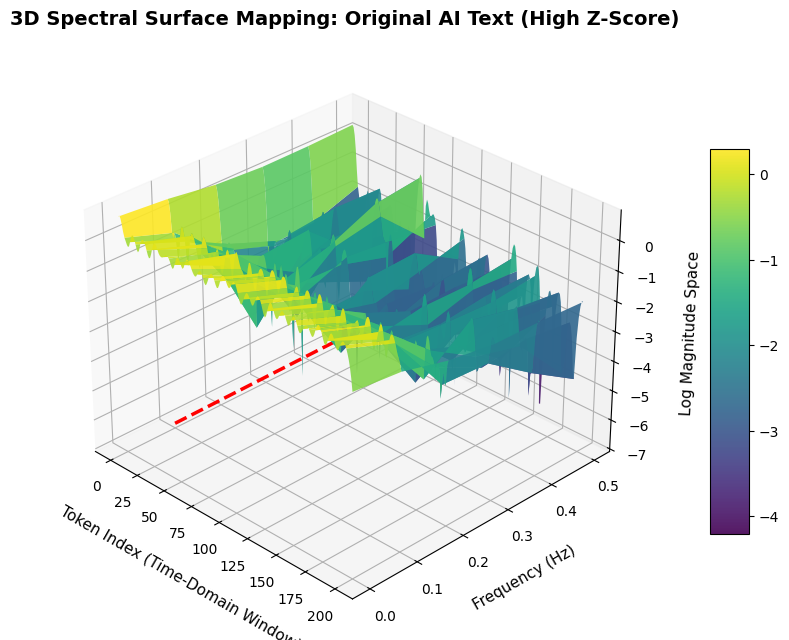

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_spectrogram(log_ranks, fs=1.0):
    """
    Generates a 3D surface spectrogram of a watermarked token rank sequence.
    log_ranks: Your 1D numpy array of stabilized log ranks (\ln(R+1))
    fs: Sampling frequency (1 token per step = 1.0)
    """
    # 1. Compute the STFT parameters matching your pipeline
    frequencies, times, Zxx = stft(log_ranks, fs=fs, nperseg=10, noverlap=9)
    
    # Convert magnitude to log scale (dB-like) for the Z-axis to match the professor's style
    log_magnitude = np.log(np.abs(Zxx) + 1e-6)
    
    # 2. Create meshgrid for 3D plotting
    X, Y = np.meshgrid(times, frequencies)
    
    # 3. Initialize 3D plot
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # 4. Plot the surface
    # 'cmap="viridis"' or 'cmap="plasma"' provides a high-contrast engineering aesthetic
    surface = ax.plot_surface(X, Y, log_magnitude, cmap='viridis', 
                              edgecolor='none', alpha=0.9)
    
    # 5. Accentuate the target watermark frequency line (0.1 Hz)
    # This draws a clear reference line across the 3D space to guide the professor's eye
    target_freq = 0.1
    ax.plot([times.min(), times.max()], [target_freq, target_freq], [log_magnitude.min(), log_magnitude.max()],
            color='red', linestyle='--', linewidth=2.5, label='Watermark Target (0.1 Hz)')
    
    # 6. Labels and View Angle
    ax.set_title('3D Spectral Surface Mapping: Original AI Text (High Z-Score)', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Token Index (Time-Domain Window)', fontsize=11, labelpad=10)
    ax.set_ylabel('Frequency (Hz)', fontsize=11, labelpad=10)
    ax.set_zlabel('Log Magnitude Space', fontsize=11, labelpad=10)
    
    # Adjust rotation angle to view the "ridge" clearly (elevation, azimuth)
    ax.view_init(elev=30, azim=-45)
    
    # Add color bar profile
    fig.colorbar(surface, ax=ax, shrink=0.5, aspect=10, pad=0.1)
    
    plt.tight_layout()
    plt.savefig('3d_watermark_spectrogram.png', dpi=300)
    plt.show()

# To run this, pass the processed log-rank array of your best original_ai text row:
plot_3d_spectrogram(best_ranks)

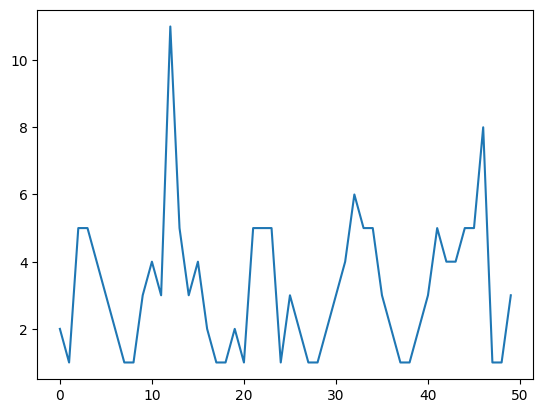

In [26]:
plt.plot(ranks_orig[:50])

In [27]:
print(ranks_human)

[  3   1   2   2   3   2   2   1   4   1   2  27   2   1   1  10   1   1
   1  39   4   2  29  12  54   1   2   1   1  11   6  14  10  11   2   1
   1   1   1   1  25 133   4  26  17   1   1   2  35   1   2   7   2   1
 297   1]


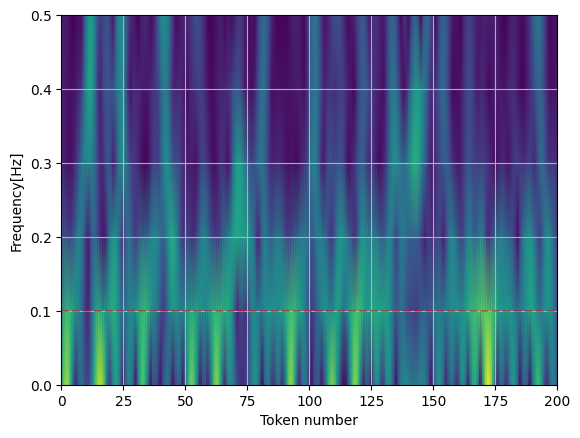

In [18]:
from scipy.signal import stft
fs = 1

signal = np.log(np.clip(ranks_orig, 1, 5) + 1)
signal = signal - np.mean(signal)

f, t ,Zxx = stft(signal, fs, nperseg = 10,  window = "hann", noverlap = 9)

plt.figure()
plt.pcolormesh(t,f,np.abs(Zxx),vmin=0, shading = 'gouraud')
plt.axhline(0.1, color='red', linestyle='--', alpha=0.5, label='Watermark (0.1Hz)')
plt.ylabel('Frequency[Hz]')
plt.xlabel('Token number')
plt.grid()
plt.show()

In [29]:
print(ranks_attacked)

[3245  146    6    4    6    2    1   12    1    1    4    9    1    3
    1    1    1    2    7    4   13    4    6    2   31    7   17   13
   10  950   15   64  134    5    1    1    3   24   21    4    8    1
    2    3    1    1    2    4    8   10    4    4  201    1    1    1
    2    6    4    3   10    2    5    2    1    1    2   30    4   20
    2    3    1    1    4    1    4    8    4    7    6    3    4    1
    1    1]


#### Detect the frequency

In [ ]:
import numpy as np
from scipy.signal import stft

def calculate_stft_peak_zscore(ranks, target_freq=0.1, nperseg=10, noverlap=9):
    WARMUP_TOKENS = 15


    ranks = np.log1p(ranks.astype(float)[WARMUP_TOKENS:])

    actual_nperseg = min(len(ranks), nperseg)
    actual_noverlap = min(noverlap, actual_nperseg - 1)

    if actual_nperseg < 2:
        return 0.0

    x = ranks - np.mean(ranks)

    freqs, times, Zxx = stft(
        x, fs=1.0, window='hann',
        nperseg=actual_nperseg, noverlap=actual_noverlap,
        boundary=None, padded=False
    )


    magnitudes = np.abs(Zxx)
    avg_spectrum = (np.mean(magnitudes, axis=1)
                    if magnitudes.ndim > 1 and magnitudes.shape[1] > 0
                    else magnitudes.flatten())


    target_bin = np.argmin(np.abs(freqs - target_freq))
    bg_powers = np.delete(avg_spectrum, target_bin)

    if len(bg_powers) == 0:
        return 0.0

    return (avg_spectrum[target_bin] - np.mean(bg_powers)) / (np.std(bg_powers) + 1e-8)


def autocorrelation_check(ranks, target_lag=10):

    if len(ranks) < 20:
        return True 

    x = ranks - np.mean(ranks)

    
    acf = np.correlate(x, x, mode='full')[len(x) - 1:]
    acf = acf / (acf[0] + 1e-8) 


    local_acf = acf[5:20]
    dominant_lag = np.argmax(local_acf) + 5 

    return dominant_lag == target_lag


def detect_watermark_zscore(ranks, min_window=80, step=20, **kwargs):

    ranks = np.asarray(ranks)
    n = len(ranks)

    adaptive_window = min(min_window, max(20, n // 3))
    adaptive_step = max(5, adaptive_window // 4)

    # If text is shorter
    if n < adaptive_window:
        score = calculate_stft_peak_zscore(ranks, **kwargs)
       
        if not autocorrelation_check(ranks.astype(float)):
            score *= 0.5
        return score

    # Slide window 
    window_scores = np.array([
        calculate_stft_peak_zscore(ranks[i:i + adaptive_window], **kwargs)
        for i in range(0, n - adaptive_window + 1, adaptive_step)
    ])

    mean_z = float(np.mean(window_scores))

    if not autocorrelation_check(ranks.astype(float)):
        mean_z *= 0.5

    return mean_z



In [ ]:
# Quick frequency bins check
ranks_test = np.ones(200) 
x = ranks_test - np.mean(ranks_test)
freqs, _, _ = stft(x, fs=1.0, window='hann', nperseg=10, noverlap=9,
                   boundary=None, padded=False)
print(f"Frequency bins: {freqs}")
print(f"Target bin index: {np.argmin(np.abs(freqs - 0.1))}")
print(f"Frequency at target bin: {freqs[np.argmin(np.abs(freqs - 0.1))]}")

Frequency bins: [0.  0.1 0.2 0.3 0.4 0.5]
Target bin index: 1
Frequency at target bin: 0.1


In [ ]:
import numpy as np
prompt = "11:03: The T-Mobile-Google MyTouch 3G Launch event at the Skyline Studios on the west side. This event is a much more casual affair than the G1 launch from last September. There's no agenda in the"
best_text = """presentation; T-Mobile will announce MyTouch 3G as its official 3G phone, but there is some talk about MyTouch 3G not making as good as an Android phone as a 3G-only model, but that's a matter of debate between Android developers and T-Mobile.\n10:00: I've been to the T-Mobile event in Las Vegas and the MyTouch launch was much smaller in scope, so I'm going for an afternoon visit today.\n9:00am PDT (3 pm BST, 4 pm CET) -- 1 hour until T-Mobile's event begins, with no announcement on MyTouch 3G's arrival, just an invitation to the MySpace T-Mobile fan group to join the event. The fan-group has over 2,000 fans. T-Mobile says the fan-group is the first in its "Fan-Club Program" for the T-Mobile mySpoke service.\n8:30pm -- I have to admit I'm not really"""
best_ranks = recover_ranks_prompt(prompt,best_text,model,tokenizer)[1:]
best_log_ranks = np.log1p(best_ranks.astype(float))

best_ranks

array([ 4,  4,  1,  4,  3,  3,  1,  1,  1,  1,  4,  7,  4,  6,  1,  1,  1,
        1,  2,  4,  4,  7,  4,  1,  5,  1,  1,  1,  1,  3,  4,  8,  5,  4,
        2,  4,  1,  1,  4,  5,  1,  1,  7,  4,  3,  2,  1,  1,  2,  2,  1,
        6,  7,  4,  3,  2,  1,  1,  2, 13,  1, 28,  1,  2,  6,  1,  3,  1,
        3,  1,  2,  5, 11,  1,  2,  2,  1,  1,  2,  3,  4,  4,  5,  4,  3,
        2,  1,  1,  2,  4,  4,  5, 10,  4,  3,  5,  1,  2,  2,  6,  4,  6,
        6,  4,  3,  1,  1,  1,  2,  2,  2,  5,  4,  5,  3,  2,  1,  1,  3,
        2,  5,  5,  5,  4,  3,  2,  1,  1,  1,  1,  5,  5,  6,  5,  3,  2,
        1,  1,  2,  3,  4,  1,  9,  4,  3,  2,  1,  1,  2,  2,  4,  5,  5,
        4,  1,  2,  1,  1,  2,  3,  4,  1,  5,  4,  3,  2,  1,  1,  2,  3,
        4,  5, 10,  4,  3,  2,  1,  1,  2,  3,  1,  5,  9,  5,  3,  2,  1,
        1,  2,  2,  4,  5,  4,  3,  3,  2,  1,  1,  2])

In [ ]:
human = "largest gas reserves, has been struggling to kick-start LNG projects in Russia amid global financial turmoil and recent discoveries of vast unconventional gas resources in the United States.\nThe gas from Brunei LNG could be purchased after 2013 when current contracts expire, reports Vedomosti, citing documents prepared for Gazprom's board.\nA Memorandum of Cooperation between Gazprom and the Government of Brunei was signed in June, reported The Brunei Times. But the details were not disclosed. A Gazprom spokeswoman would not comment.\nBrunei LNG is half-owned by Brunei, with Japanese group Mitsubishi and Anglo-Dutch company Shell each owning 25%.\nHowever, two sources close to Russia’s state-owned giant say Gazprom needs a guarantee of non-stop deliveries: in 2009 Gazprom set up subsidiary GM & T Singapore, which was intended to develop Russian gas deliveries to the promising Asian region.\nIt is actively searching for Asian customers, but Gazprom’s LNG resources are limited. Russia's only LNG plant	"
human_ranks = recover_ranks_prompt(human,model,tokenizer)


z_score_best = detect_watermark_zscore(best_ranks,target_freq = 0.1,
    nperseg= 10,
    noverlap= 9)

z_score_best_updated = detect_watermark_zscore(best_ranks_updated,target_freq = 0.1,
    nperseg= 10,
    noverlap= 9)

z_score_human = detect_watermark_zscore(human_ranks,target_freq = 0.1,
    nperseg= 10,
    noverlap= 9)

print(z_score_best, z_score_best_updated,z_score_human)

5.340060096960547 1.5711931138122146 0.5129098377641568


##### Now Lets make a database

In [ ]:
z_score_best_updated = detect_watermark_zscore(best_ranks_updated,target_freq = 0.1,
    nperseg= 10,
    noverlap= 9)

print(z_score_best, z_score_best_updated)

In [ ]:
import pandas as pd
from tqdm import tqdm 

categories = [
    ('human_baseline', 0), 
    ('original_ai', 1),    
    ('translated', 1),     
    ('substituted', 1),    
    ('paraphrased', 1),    
    ('mixed_text', 1)
]


processed_rows = []
print("Starting Detection Gauntlet")

for i, entry in enumerate(tqdm(final_dataset)):
    prompt = entry['prompt']

    for key, label in categories:
        text_to_test = entry[key]

        if not text_to_test or len(text_to_test.strip()) == 0: 
            continue

        # 1. Calculate Watermark Z-Score
        ranks = recover_ranks_prompt(prompt, text_to_test, model, tokenizer)
        z = detect_watermark_zscore(ranks)
        
        # 2. Calculate Perplexity
        ppl_value = get_ppl(text_to_test)

        processed_rows.append({
            'sample_id': i,
            'text_type': key,
            'label': label,
            'z_score': z,
            'perplexity': ppl_value,  # Added PPL here
            'prompt_text': prompt, 
            'generated_text': text_to_test
        })

# Create DataFrame
df = pd.DataFrame(processed_rows)

# Save to CSV
output_file = 'freqmark_dataset_0.5.csv'
df.to_csv(output_file, index=False)

print(f"\n Done! Saved {len(df)} labeled samples to '{output_file}'")

🚀 Starting Detection Gauntlet...


100%|██████████| 500/500 [2:54:00<00:00, 20.88s/it]  


✅ Done! Saved 3000 labeled samples to 'freqmark_dataset_again0.5.csv'


#### Here we tried various z-score calculation techniques

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# Load master CSV
df = pd.read_csv("freqmark_master_final.csv")

print(f"Loaded {len(df)} rows. Recalculating z-scores...")

new_z_scores = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    prompt = row['prompt_text']
    text   = row['generated_text']

    # Skip empty rows
    if not text or len(str(text).strip()) == 0:
        new_z_scores.append(0.0)
        continue

    # Recover ranks
    ranks = recover_ranks_prompt(prompt, str(text), model, tokenizer)

    # Recalculate z-score with updated function
    if len(ranks) == 0:
        new_z_scores.append(0.0)
    else:
        z = detect_watermark_zscore(ranks)
        new_z_scores.append(z)

# Replace old z-scores with new ones
df['z_score_old'] = df['z_score']   # keep old for comparison
df['z_score']     = new_z_scores

# Save updated CSV
df.to_csv("freqmark_master_updated.csv", index=False)
print(f"\n Done! Saved updated z-scores to 'freqmark_master_updated.csv'")

# Quick sanity check
print("\nMean z-score by text type (new vs old):")
print(df.groupby('text_type')[['z_score', 'z_score_old']].mean().round(3))


# Detailed check: How does intensity affect z-score?
print("\nMean z-score by Attack Intensity:")
print(df.groupby(['text_type', 'attack_percentage'])['z_score'].mean())

Loaded 15000 rows. Recalculating z-scores...


100%|██████████| 15000/15000 [27:46<00:00,  9.00it/s]



✅ Done! Saved updated z-scores to 'freqmark_master_updated.csv'

Mean z-score by text type (new vs old):
                z_score  z_score_old
text_type                           
human_baseline    0.301        0.946
mixed_text        1.007        1.633
original_ai       2.776        3.410
paraphrased       1.108        2.354
substituted       1.068        2.438
translated        1.698        3.175

Mean z-score by Attack Intensity:
text_type       attack_percentage
human_baseline  0.1                  0.301344
                0.2                  0.301344
                0.3                  0.301344
                0.4                  0.301344
                0.5                  0.301344
mixed_text      0.1                  1.341114
                0.2                  1.192240
                0.3                  1.019804
                0.4                  0.837285
                0.5                  0.646064
original_ai     0.1                  2.776307
                0.2    

In [ ]:
paraphrased_ranks = recover_ranks_prompt(final_dataset[11]['prompt'],final_dataset[11]['human_baseline'],model,tokenizer)
paraphrased_ranks

array([  3, 212,   1,   2,   1,  10,   8,  40,   4,  24,   1,   1,  25,
        14,  41,   1,   1,   1,   3,   4,   9,   4,   1,   1,   1,  28,
         1,   3,   5, 116,   1,   1,  13,  14,   1, 971,   1,   1,   1,
         2,   1,   1,   1,   5,   7,   1,   1,   4,  16,   1,  10,   2,
         1,   1,   1,   1,   1,   1,   2,   4,   2,   9,   1,  13,   1,
         5,   2,   1,   2,   1,  16,   3,   2,   1,   3,   1,   2,   1,
         1,   1,   1,   2,   4,  10,   1,   1,   1,   1, 767,   9,  13,
         7,   3,   1,   1,   1,   1,   2,  26,   2])

In [39]:
detect_watermark_zscore(paraphrased_ranks)

np.float64(4.813316902216739)

In [ ]:
human = """15 was ask Joseph Kennedy for his driver's license -- while Shabazian was sitting in his cruiser and Kennedy was walking by.\nDistrict Justice Edward Lewis of Jim Thorpe tossed out the escape charge and a summary offense of failing to produce a driver's license when asked. Lewis convicted Kennedy of driving on the wrong side of the road and imposed a $25 fine.\nShabazian, the only witness at the brief hearing, said that fellow Patrolman Robert Transue was driving the cruiser about 2 a.m. Sept. 15. Shabazian said he and Transue saw a step van cross the center line several times as it came up North Street.\nThe van turned and the driver parked at Kennedy's home. Transue pulled the cruiser alongside the van. Kennedy was out of the van, and Shabazian, while still inside the van, asked Kennedy for his driver's license. Kennedy said his license was inside the house, turned and walked away. Sh	"""
human_ranks = recover_ranks_prompt(prompt,human,model,tokenizer)
human_ranks

array([ 745,    2,    1,   11,   94,    6,    1,    3,    1,    1,   24,
         43,   14,    1,    1,    1,    1,    6,    1,    3,    4,   11,
          1,    1,    2,   15,    1,   70,    4,    9,  132,   33,    3,
          1,    1,  180,    1,    1,   33,    1,    3,   16,   49,    6,
          1,   13,    1,    1,    1,    1,    1,    1,    9,   12,   11,
         29,   89,    1,    1,    2,    6,    2,    1,    1,    1,    1,
          1,    2,   40,    1,    1,    9,    1,    1,    3,    1,    1,
          1,    1,    5,    2,    1,    6,    1,    8,    1,    1,    1,
          3,  294,    8,    1,    2, 5320,    1,    4,    2,    1,    1,
         31,    1,    4,    3,    1,    1,    3,    1,    1,    1,    3,
          2,    1,    1,    1,    1,    1,    4,    1,    1,    4,    2,
       1738,    7,   53,    1,    1,    1,   46,    1,    6,    2,   14,
          3,   34,    5,    1,    3,    1,   11,   12,   13,    1,   59,
          9,    6,    1,    1,    1,    4,    1,   

#### Here we look at human ranks replicating signal pattern

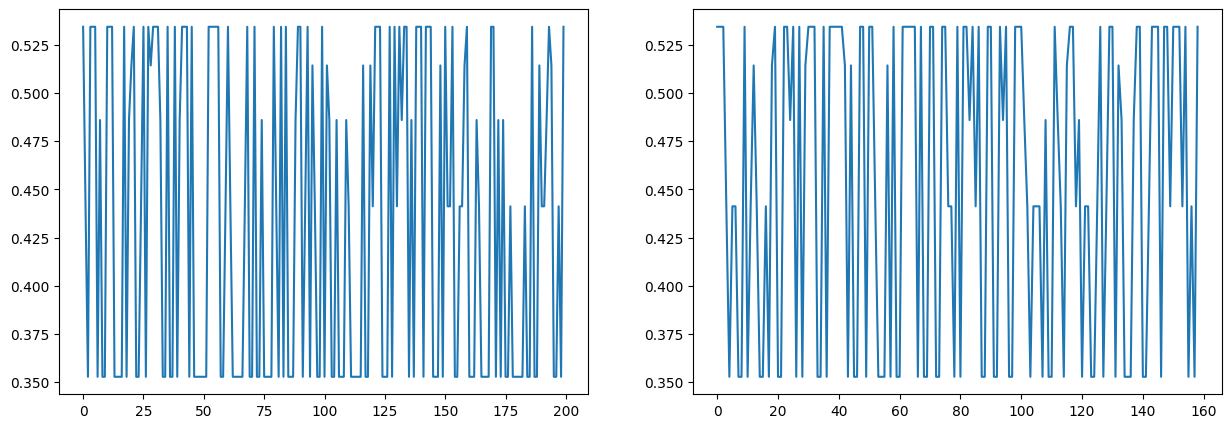

In [ ]:
import matplotlib.pyplot as plt

def process_ranks(ranks):
        # Instead of: ranks = np.clip(ranks, 1, 5)
    # Use:
    x = np.log(ranks + 1) 
    limit = np.percentile(x, 95) # 
    x = np.clip(x, None, limit)
    return x


human_ranks = process_ranks(human_ranks)
bad_para = process_ranks(bad_para)
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(15,5))
ax1.plot(human_ranks,label ='human_ranks')
ax2.plot(bad_para,label ='substituted_ranks')


#### here we checked the perplexity of some texts 

In [34]:
# Select 2 samples from each type to test
sample_types = df['text_type'].unique()
results = []

print("Running sanity check on Perplexity...")

for t_type in sample_types:
    subset = df[df['text_type'] == t_type].head(2)
    for _, row in subset.iterrows():
        ppl = get_ppl(row['generated_text'])
        results.append({'text_type': t_type, 'perplexity': ppl})

# Display results
sanity_check_df = pd.DataFrame(results)
print(sanity_check_df)

Running sanity check on Perplexity...
         text_type  perplexity
0   human_baseline   23.973419
1   human_baseline   40.843876
2      original_ai   20.581997
3      original_ai   20.665991
4       translated   20.944941
5       translated   20.023861
6      substituted   21.229765
7      substituted   20.159986
8      paraphrased   27.091631
9      paraphrased   25.271101
10      mixed_text   27.638926
11      mixed_text   25.452065


### Frequency Analysis of Ranks

In [7]:
import pandas as pd

In [8]:
df = pd.read_csv("freqmark_master_final.csv")

### let's compute SNR for 50 samples

Sampled 48 rows
text_type
human_baseline    8
original_ai       8
translated        8
substituted       8
paraphrased       8
mixed_text        8
Name: count, dtype: int64
  processed 10/50
  processed 20/50
  processed 30/50
  processed 40/50

Mean SNR by text type:
text_type
original_ai       1.977
translated        1.629
substituted       1.408
paraphrased       1.269
mixed_text        1.267
human_baseline    0.990
Name: snr, dtype: float64


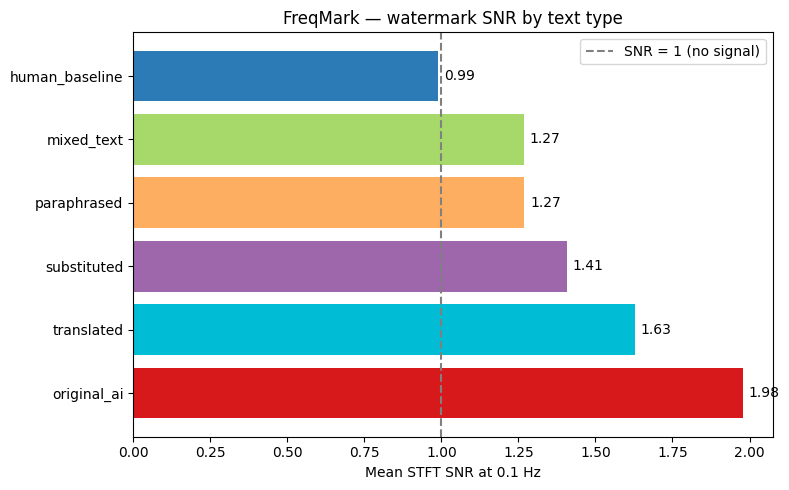

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import stft



def balanced_sample(df, total=50, seed=42):
    np.random.seed(seed)
    text_types = df["text_type"].unique()
    per_type   = total // len(text_types)
    sampled    = []

    for t in text_types:
        rows = df[df["text_type"] == t]
        n    = min(per_type, len(rows))
        sampled.append(rows.sample(n, random_state=seed))

    return pd.concat(sampled).reset_index(drop=True)



def compute_snr(ranks, window=10, target_freq=0.1):
    """
    Runs STFT on the log-transformed rank sequence and computes Power SNR.

    """
   
    if len(ranks) < window:
        return 1.0
    
    log_ranks = np.log(ranks.astype(float))
    ranks_centered = log_ranks - np.mean(log_ranks)
    
    freqs, times, Zxx = stft(
        ranks_centered,
        fs=1.0,
        window="hann",
        nperseg=window,
        noverlap=window - 1, 
    )

   
    power_spectrum = np.abs(Zxx) ** 2


    avg_power = power_spectrum.mean(axis=1)

    #for DC
    target_idx = np.argmin(np.abs(freqs - target_freq))
    
    # Peak power at the watermark frequency
    peak = avg_power[target_idx]

    #for noise
    noise_mask = np.ones(len(freqs), dtype=bool)
    noise_mask[0] = False          # Eliminate 0 Hz DC offset
    noise_mask[target_idx] = False # Eliminate the watermark signal itself
    
    # Average the remaining active background static power bins
    noise = np.mean(avg_power[noise_mask]) if np.any(noise_mask) else 1e-9

    snr = peak / (noise + 1e-9)
    return snr



def run_analysis(df, model, tokenizer):
    sample_df = balanced_sample(df, total=50)
    print(f"Sampled {len(sample_df)} rows")
    print(sample_df["text_type"].value_counts())

    results = []
    for i, row in sample_df.iterrows():
        ranks = recover_ranks_prompt(row["generated_text"], model, tokenizer)
        snr   = compute_snr(ranks)

        results.append({
            "text_type": row["text_type"],
            "label":     row["label"],
            "n_tokens":  len(ranks),
            "snr":       snr,
        })

        if (len(results)) % 10 == 0:
            print(f"  processed {len(results)}/50")

    return pd.DataFrame(results)




def plot_results(results_df):
    # summary table
    summary = results_df.groupby("text_type")["snr"].mean().sort_values(ascending=False)
    print("\nMean SNR by text type:")
    print(summary.round(3))

    # bar chart
    colors = {
        "human_baseline": "#2c7bb6",
        "original_ai":    "#d7191c",
        "paraphrased":    "#fdae61",
        "mixed_text":     "#a6d96a",
        "substituted":    "#9e66ab",
        "translated":     "#00bcd4",
    }
    bar_colors = [colors.get(t, "gray") for t in summary.index]

    plt.figure(figsize=(8, 5))
    bars = plt.barh(summary.index, summary.values, color=bar_colors)
    plt.bar_label(bars, fmt="%.2f", padding=4)
    plt.axvline(1.0, color="gray", linestyle="--", label="SNR = 1 (no signal)")
    plt.xlabel("Mean STFT SNR at 0.1 Hz")
    plt.title("FreqMark — watermark SNR by text type")
    plt.legend()
    plt.tight_layout()
    plt.savefig("freqmark_snr.png", dpi=150)
    plt.show()


results_df = run_analysis(df, model, tokenizer)
plot_results(results_df)

#### Run SNR on the entire dataset for final numbers
Since we  already have the final datset we used it to calculate SNR

  500/15000 done
  1000/15000 done
  1500/15000 done
  2000/15000 done
  2500/15000 done
  3000/15000 done
  3500/15000 done
  4000/15000 done
  4500/15000 done
  5000/15000 done
  5500/15000 done
  6000/15000 done
  6500/15000 done
  7000/15000 done
  7500/15000 done
  8000/15000 done
  8500/15000 done
  9000/15000 done
  9500/15000 done
  10000/15000 done
  10500/15000 done
  11000/15000 done
  11500/15000 done
  12000/15000 done
  12500/15000 done
  13000/15000 done
  13500/15000 done
  14000/15000 done
  14500/15000 done
  15000/15000 done


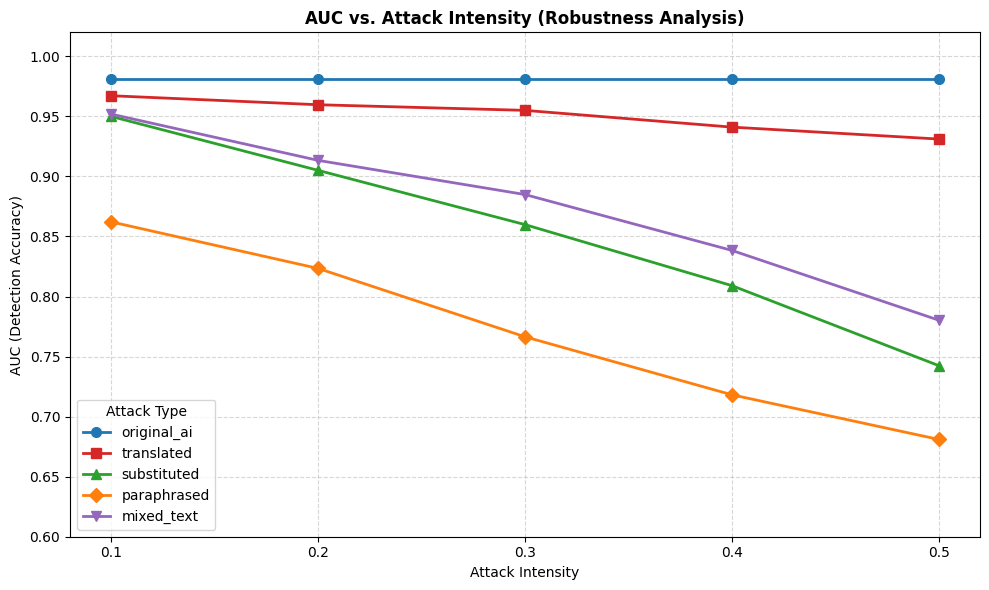

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import stft
from sklearn.metrics import roc_auc_score


def compute_snr(ranks, window=10, target_freq=0.1,skip_first=10):

    if len(ranks) < window:
        return 1.0
    ranks = ranks[skip_first:]
    
    log_ranks = np.log(ranks.astype(float))
    ranks_centered = log_ranks - np.mean(log_ranks)
    
    freqs, times, Zxx = stft(
        ranks_centered,
        fs=1.0,
        window="hann",
        nperseg=window,
        noverlap=window - 1,   # hop = 1, matching the paper
    )

    power_spectrum = np.abs(Zxx) ** 2


    avg_power = power_spectrum.mean(axis=1)


    target_idx = np.argmin(np.abs(freqs - target_freq))
    
    # Peak power at the watermark frequency
    peak = avg_power[target_idx]


    noise_mask = np.ones(len(freqs), dtype=bool)
    noise_mask[0] = False         
    noise_mask[target_idx] = False 

    noise = np.mean(avg_power[noise_mask]) if np.any(noise_mask) else 1e-9

    snr = peak / (noise + 1e-9)
    return snr


def run_full_analysis(df, model, tokenizer):
    results = []

    for i, row in df.iterrows():
        ranks = recover_ranks_prompt(row["generated_text"], model, tokenizer)
        results.append({
            "text_type":        row["text_type"],
            "label":            row["label"],
            "attack_percentage": row["attack_percentage"],
            "snr":              compute_snr(ranks),
        })
        if len(results) % 500 == 0:
            print(f"  {len(results)}/{len(df)} done")

    return pd.DataFrame(results)


def plot_robustness(results_df):
    attack_types = ["original_ai", "translated", "substituted", "paraphrased", "mixed_text"]
    intensities  = sorted(results_df["attack_percentage"].unique())
    human_rows   = results_df[results_df["text_type"] == "human_baseline"]

    colors  = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd"]
    markers = ["o", "s", "^", "D", "v"]

    plt.figure(figsize=(10, 6))

    for attack, color, marker in zip(attack_types, colors, markers):
        aucs = []
        for intensity in intensities:
            attack_rows = results_df[
                (results_df["text_type"] == attack) &
                (results_df["attack_percentage"] == intensity)
            ]
            # original_ai has no varying intensity so fall back to all rows
            if len(attack_rows) == 0:
                attack_rows = results_df[results_df["text_type"] == attack]

            subset = pd.concat([human_rows, attack_rows])
            auc    = roc_auc_score(subset["label"], subset["snr"])
            aucs.append(auc)

        plt.plot(intensities, aucs, label=attack, color=color,
                 marker=marker, linewidth=2, markersize=7)

    plt.xlabel("Attack Intensity")
    plt.ylabel("AUC (Detection Accuracy)")
    plt.title("AUC vs. Attack Intensity (Robustness Analysis)", fontweight="bold")
    plt.legend(title="Attack Type")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.ylim(0.6, 1.02)
    plt.xticks(intensities)
    plt.tight_layout()
    plt.savefig("freqmark_robustness.png", dpi=150)
    plt.show()


results_df = run_full_analysis(df, model, tokenizer)
results_df.to_csv("freqmark_snr_results.csv", index=False)


results_df = pd.read_csv("freqmark_snr_results.csv")

plot_robustness(results_df)

#### Quick check on preprocessing methods on ranks.

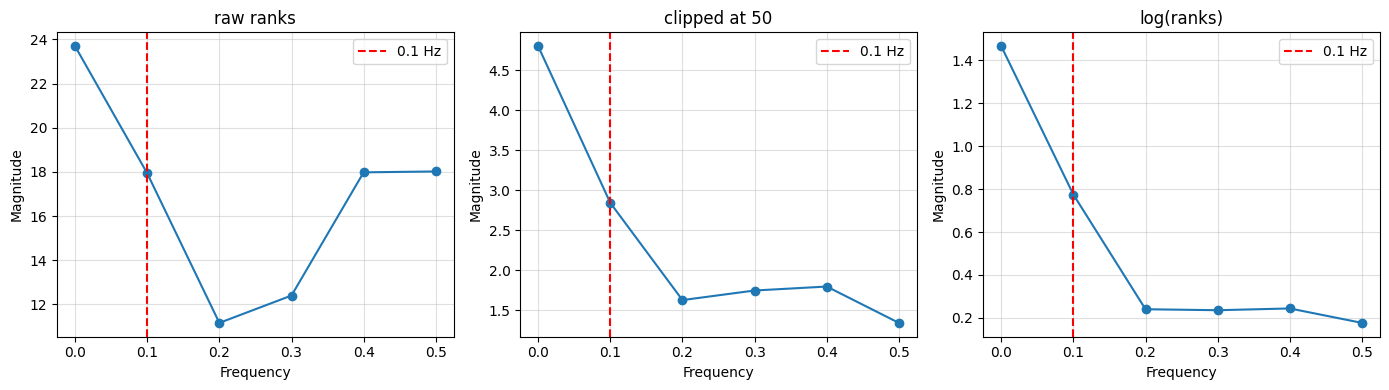

In [ ]:

ranks = recover_ranks_prompt(df[df["text_type"]=="original_ai"].iloc[0]["generated_text"], model, tokenizer)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (label, transformed) in zip(axes, [
    ("raw ranks",        ranks),
    ("clipped at 50",    np.clip(ranks, 1, 50)),
    ("log(ranks)",       np.log(ranks + 1)),
]):
    freqs, _, Zxx = stft(transformed.astype(float), fs=1.0,
                         window="hann", nperseg=10, noverlap=9)
    avg_mag = np.abs(Zxx).mean(axis=1)
    ax.plot(freqs, avg_mag, marker="o")
    ax.axvline(0.1, color="red", linestyle="--", label="0.1 Hz")
    ax.set_title(label)
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Magnitude")
    ax.legend()
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()